# 04224 — Lập trình cho Trí tuệ nhân tạo và Khoa học dữ liệu
## Tuần 2 — Bài thực hành trên lớp
### Trực quan hóa dữ liệu; xử lý dữ liệu thiếu và nhiễu

**Trường Đại học Hùng Vương TP. Hồ Chí Minh — Khoa Kỹ thuật Công nghệ**

| | |
|---|---|
| **Chuẩn đầu ra** | CLO2 (trực quan hóa), CLO3 (làm sạch và chuẩn bị dữ liệu), CLO4 (phân tích và diễn giải) |
| **Thời lượng** | 3 tiết (~150 phút) — thực hành có giám sát tại phòng máy |
| **Môi trường** | Jupyter Notebook / JupyterLab |
| **Dữ liệu** | `../lab_data/sinhvien.csv`, `../lab_data/banhang_raw.csv` |

**Cuối buổi bạn nộp bốn thứ**

1. Chính notebook này, **đã chạy từ trên xuống dưới không lỗi** (Kernel → Restart Kernel and Run All Cells).
2. `tuan02_6bieudo.png` — bảng 6 biểu đồ, lưu ở 300 dpi.
3. `banhang_sach.csv` — tệp bán hàng đã làm sạch.
4. **Nhật ký làm sạch** — ô markdown ở cuối Task 3, mỗi quyết định đi kèm một lý do.

**Phân bổ thời gian**

| Task | Nội dung | Thời gian |
|:--:|---|:--:|
| 1 | Bảng 6 biểu đồ có nhãn đầy đủ | ~35 phút |
| 2 | Hàm `profile(df)` dùng lại được | ~25 phút |
| 3 | Làm sạch `banhang_raw.csv` | ~60 phút |
| 4 | So sánh ba chiến lược điền khuyết | ~30 phút |
| + | Mở rộng (tự chọn) — Seaborn | nếu còn thời gian |

> **Nguyên tắc xuyên suốt buổi hôm nay.** Mọi thao tác làm sạch là một **quyết định phân tích**, không phải một bước dọn dẹp tùy hứng. Một quyết định không ghi lại được thì không lặp lại được; không lặp lại được thì không bảo vệ được trước người đọc báo cáo.

---
## 0. Chuẩn bị

Chạy ô dưới đây trước tiên. Nếu nó báo `FileNotFoundError`, notebook của bạn đang nằm sai chỗ: nó phải ở trong thư mục `lab_exercises/`, **ngang hàng** với `lab_data/`.

**Kết quả mong đợi**

```
sinhvien.csv    : (1200, 9)
banhang_raw.csv : (928, 8)
```

In [1]:
# --- Thư viện dùng chung cho cả buổi thực hành ---
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.30

print("pandas", pd.__version__, "| numpy", np.__version__,
      "| matplotlib", matplotlib.__version__, "| seaborn", sns.__version__)

DATA_DIR = "../lab_data"

def load_csv(filename):
    """Đọc một CSV trong ../lab_data/ và báo lỗi rõ ràng nếu không tìm thấy."""
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(
            "Không tìm thấy '" + path + "'.\n"
            "Thư mục làm việc hiện tại: " + os.getcwd() + "\n"
            "Notebook phải nằm trong lab_exercises/, ngang hàng với thư mục lab_data/."
        )
    return pd.read_csv(path)

sv  = load_csv("sinhvien.csv")       # 1200 x 9
raw = load_csv("banhang_raw.csv")    # 928 x 8
print("sinhvien.csv    :", sv.shape)
print("banhang_raw.csv :", raw.shape)

pandas 3.0.3 | numpy 2.4.6 | matplotlib 3.11.0 | seaborn 0.13.2
sinhvien.csv    : (1200, 9)
banhang_raw.csv : (928, 8)


---
# Task 1 — Bảng 6 biểu đồ (~35 phút)

**Mục tiêu.** Từ `sinhvien.csv`, dựng **sáu** biểu đồ trong **một** figure `2 x 3` và lưu ở chất lượng in ấn.

**Sáu ô, đúng thứ tự này**

| Ô | Vị trí | Biểu đồ | Dữ liệu |
|:--:|:--:|---|---|
| 1 | `axes[0,0]` | Histogram | phân phối `gpa` |
| 2 | `axes[0,1]` | Box plot | `gpa` tách theo `khoa` |
| 3 | `axes[0,2]` | Scatter | `gio_tu_hoc` (trục X) và `gpa` (trục Y) |
| 4 | `axes[1,0]` | Bar | số sinh viên theo `khoa` |
| 5 | `axes[1,1]` | Line | số sinh viên nhập học theo `ngay_nhap_hoc` |
| 6 | `axes[1,2]` | Heatmap | ma trận tương quan các cột số |

**Các bước**

1. Bỏ các dòng thiếu `gpa` trước khi vẽ ô 1–3 (`dropna`), và ghi số `n` thực tế vào title.
2. Vẽ từng ô bằng API hướng đối tượng: `ax = axes[0, 0]` rồi `ax.hist(...)` — **không** dùng `plt.hist(...)`.
3. Mỗi ô phải có `set_xlabel`, `set_ylabel`, `set_title`, và nhãn trục phải ghi cả **đơn vị**.
4. Ô 6 là ngoại lệ có lý do: tên biến nằm trên tick của hai trục, còn đơn vị nằm ở **colorbar** — nên colorbar bắt buộc có nhãn.
5. Lưu: `fig.savefig(FIG_FILE, dpi=300, bbox_inches="tight")`.

> **Nói thẳng: một trục không có nhãn là một LỖI, không phải một lựa chọn thẩm mỹ.** "GPA" chưa đủ — người đọc không biết 3.2 là cao hay thấp nếu không biết thang điểm. Phải là "GPA (thang điểm 4.0)". Ô tự kiểm tra bên dưới sẽ bắt lỗi này.

**Kết quả mong đợi**

- Ô tự kiểm tra in `Task 1 ĐẠT: ...`
- File `tuan02_6bieudo.png` tồn tại, khoảng **0.9–1.0 MB** (nếu chỉ vài chục KB thì bạn quên `dpi=300`).
- Ô 1: phân phối gần chuẩn, đỉnh quanh **2.6**, n = **1145**.
- Ô 3: tương quan `r ≈ 0.23` — dương nhưng **yếu**; 1145 điểm chồng nhau nên phải dùng `alpha`.
- Ô 6: `nam_hoc`–`gpa` ≈ **0.26**, `gio_tu_hoc`–`gpa` ≈ **0.23**, `so_tin_chi` gần như không tương quan với gì.

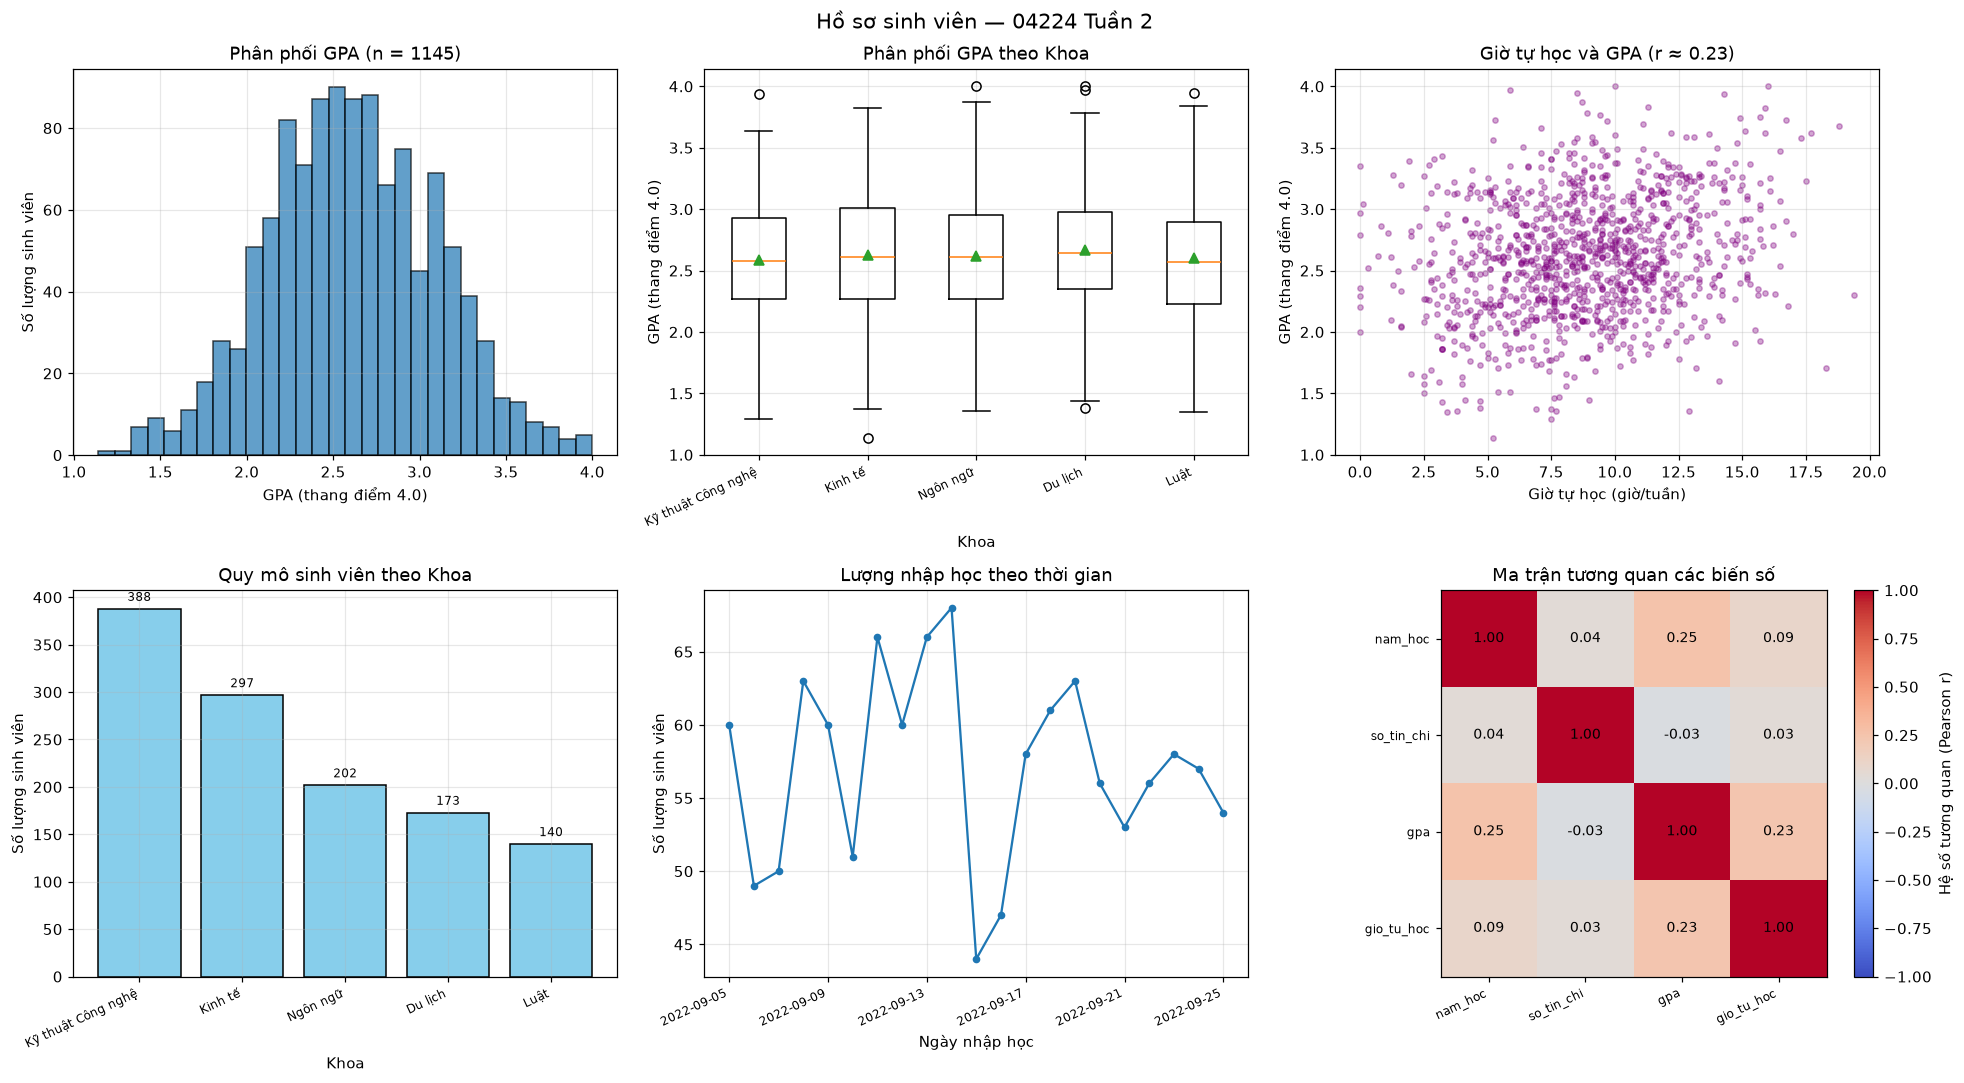

In [3]:
FIG_FILE = "tuan02_6bieudo.png"
sv_gpa = sv.dropna(subset=["gpa"])          # 1145 dòng có GPA

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# (1) Histogram — phân phối GPA -------------------------------------------
ax = axes[0, 0]
ax.hist(sv_gpa["gpa"], bins=30, edgecolor="black", alpha=0.7)
ax.set_xlabel("GPA (thang điểm 4.0)")
ax.set_ylabel("Số lượng sinh viên")
ax.set_title(f"Phân phối GPA (n = {len(sv_gpa)})")

# (2) Box plot — GPA theo khoa --------------------------------------------
ax = axes[0, 1]
faculties = sv["khoa"].value_counts().index.tolist()
gpa_by_fac = [sv.loc[sv["khoa"] == f, "gpa"].dropna() for f in faculties]
ax.boxplot(gpa_by_fac, tick_labels=faculties, showmeans=True)
ax.set_xlabel("Khoa")
ax.set_ylabel("GPA (thang điểm 4.0)")
ax.set_title("Phân phối GPA theo Khoa")
plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=8)

# (3) Scatter — giờ tự học và GPA -----------------------------------------
ax = axes[0, 2]
d3 = sv.dropna(subset=["gpa", "gio_tu_hoc"])
r = d3["gio_tu_hoc"].corr(d3["gpa"])
ax.scatter(d3["gio_tu_hoc"], d3["gpa"], s=12, alpha=0.35, color="purple")
ax.set_xlabel("Giờ tự học (giờ/tuần)")
ax.set_ylabel("GPA (thang điểm 4.0)")
ax.set_title(f"Giờ tự học và GPA (r ≈ {r:.2f})")

# (4) Bar — số sinh viên theo khoa ----------------------------------------
ax = axes[1, 0]
counts = sv["khoa"].value_counts()
bars = ax.bar(counts.index, counts.values, color="skyblue", edgecolor="black")
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom', fontsize=8)
ax.set_xlabel("Khoa")
ax.set_ylabel("Số lượng sinh viên")
ax.set_title("Quy mô sinh viên theo Khoa")
plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=8)

# (5) Line — lượng nhập học theo ngày -------------------------------------
ax = axes[1, 1]
enrol = pd.to_datetime(sv["ngay_nhap_hoc"]).value_counts().sort_index()
ax.plot(enrol.index, enrol.values, marker="o", linestyle="-", linewidth=1.5, markersize=4)
ax.set_xlabel("Ngày nhập học")
ax.set_ylabel("Số lượng sinh viên")
ax.set_title("Lượng nhập học theo thời gian")
plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=8)

# (6) Heatmap — ma trận tương quan ----------------------------------------
ax = axes[1, 2]
num_cols = ["nam_hoc", "so_tin_chi", "gpa", "gio_tu_hoc"]
M = sv[num_cols].corr().to_numpy()
im = ax.imshow(M, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(num_cols)))
ax.set_yticks(np.arange(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=25, ha="right", fontsize=8)
ax.set_yticklabels(num_cols, fontsize=8)

for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", color="black", fontsize=9)

ax.set_title("Ma trận tương quan các biến số")
ax.grid(False)
cbar = fig.colorbar(im, ax=ax, fraction=0.046)
cbar.set_label("Hệ số tương quan (Pearson r)")

fig.suptitle("Hồ sơ sinh viên — 04224 Tuần 2", fontsize=14)
fig.tight_layout()
fig.savefig(FIG_FILE, dpi=300, bbox_inches="tight")
plt.show()

In [4]:
# --- Tự kiểm tra Task 1: trục không nhãn là một LỖI, không phải lựa chọn thẩm mỹ ---
assert axes.shape == (2, 3), "Phải là lưới 2x3"

for i, a in enumerate(axes.flat, 1):
    assert a.get_title().strip() != "", "Ô số %d chưa có title" % i

for i, a in enumerate(list(axes.flat)[:5], 1):
    assert a.get_xlabel().strip() != "", "Ô số %d chưa có nhãn trục X" % i
    assert a.get_ylabel().strip() != "", "Ô số %d chưa có nhãn trục Y" % i

# Ô số 6 là heatmap: tên biến nằm trên tick, còn đơn vị nằm ở colorbar
heat = axes[1, 2]
assert any(t.get_text().strip() for t in heat.get_xticklabels()), \
    "Heatmap chưa đặt tên biến lên trục"
extra_axes = [a for a in fig.axes if a not in list(axes.flat)]
assert extra_axes, "Heatmap chưa có colorbar"
assert any(a.get_ylabel().strip() for a in extra_axes), "Colorbar chưa có nhãn"

assert os.path.exists(FIG_FILE), "Chưa lưu file hình"
assert os.path.getsize(FIG_FILE) > 200_000, "File quá nhỏ — có chắc đã dùng dpi=300 chưa?"
print("Task 1 ĐẠT: 6 biểu đồ, đủ title + nhãn trục + colorbar có nhãn, hình 300 dpi đã lưu.")

Task 1 ĐẠT: 6 biểu đồ, đủ title + nhãn trục + colorbar có nhãn, hình 300 dpi đã lưu.


### Nhận định của bạn — mỗi biểu đồ một câu

> *(Nhấp đúp vào ô này để sửa. Một câu cho mỗi ô, nói **điều biểu đồ cho biết**, không mô tả lại hình dạng. "Phân phối hình chuông" không phải nhận định; "GPA tập trung quanh 2.6, rất ít sinh viên trên 3.5" mới là nhận định.)*

1. Histogram GPA: GPA của sinh viên tập trung chủ yếu quanh mức 2.6, với rất ít sinh viên đạt điểm xuất sắc trên 3.5 hoặc điểm dưới 1.0.
2. Box plot theo khoa: Các khoa có mức phân phối điểm trung bình (GPA) khá đồng đều nhau, dao động quanh mức 2.6 - 2.7, tuy nhiên khoa Luật có ít giá trị ngoại lai (điểm quá cao hoặc quá thấp) hơn so với các khoa còn lại.
3. Scatter giờ tự học – GPA: Có mối tương quan giữa giờ tự học và GPA, nghĩa là sinh viên dành nhiều thời gian tự học hơn có xu hướng đạt GPA cao hơn một chút, nhưng sự phân tán dữ liệu rất lớn.
4. Bar quy mô khoa: Khoa Kỹ thuật Công nghệ có quy mô sinh viên lớn nhất (388 sinh viên), trong khi khoa Luật có quy mô nhỏ nhất (148 sinh viên).
5. Line nhập học: Lượng sinh viên nhập học biến động mạnh theo từng ngày, đạt đỉnh cao nhất vào khoảng giữa tháng 9/2022 (với hơn 67 sinh viên nhập học trong ngày).
6. Heatmap tương quan: Biến nam_hoc có tương quan dương yếu với gpa, còn so_tin_chi hầu như không có tương quan với bất kỳ biến số nào khác trong bảng.   

---
# Task 2 — Hàm `profile(df)` (~25 phút)

**Mục tiêu.** Viết **một** hàm dùng được cho **mọi** DataFrame, trả về cho từng cột:

| Trường | Ý nghĩa |
|---|---|
| `dtype` | kiểu dữ liệu pandas đang hiểu |
| `n_missing` | số ô thiếu |
| `pct_missing` | tỉ lệ thiếu, tính theo % |
| `n_unique` | số giá trị duy nhất (không tính `NaN`) |
| `top_values` | 5 giá trị phổ biến nhất kèm số đếm |

**Các bước**

1. Hàm trả về một **DataFrame** (không phải `dict`, không phải chuỗi `print`) — để còn lọc, sắp xếp và đem đi dùng lại.
2. Index là tên cột, và **thứ tự cột phải giữ nguyên như trong `df`**.
3. Chạy trên cả `sinhvien.csv` lẫn `banhang_raw.csv`.
4. Hàm phải chịu được trường hợp biên: cột toàn `NaN`, và DataFrame rỗng (`len(df) == 0` — đừng chia cho 0).
5. `assert len(profile(df)) == df.shape[1]` — đúng một dòng cho mỗi cột.

> `df.describe()` **không** thay thế được hàm này: nó bỏ qua cột chuỗi và không cho biết tỉ lệ thiếu. Bạn sẽ dùng lại `profile()` ở Task 3 và ở các tuần sau.

**Kết quả mong đợi**

- `profile(sv)` — **9 dòng**. `gpa` thiếu **55 (4.58%)**, `gio_tu_hoc` thiếu **53 (4.42%)**, `tinh_tp` thiếu **14 (1.17%)**.
- `profile(raw)` — **8 dòng**, và bảng này đã đủ để lộ **bốn** khuyết tật trước khi bạn sửa dòng nào:

| Dấu hiệu trong bảng | Khuyết tật |
|---|---|
| `ma_don` có `n_unique = 900` nhưng `raw` có **928** dòng | có dòng trùng lặp |
| `kenh` có `n_unique = 4` | 4 cách viết cho 2 kênh thật |
| `thanh_tien` có `dtype = str` | số đang lưu dưới dạng chuỗi |
| `so_luong` có `dtype = float64` dù là số nguyên | có `NaN` nên pandas phải nới kiểu |

- Ô tự kiểm tra in `Task 2 ĐẠT: ...`

In [7]:
def profile(df, k=5):
    """Hồ sơ nhanh của một DataFrame bất kỳ — mỗi cột một dòng.

    Trả về DataFrame có index là tên cột và các cột:
      dtype, n_missing, pct_missing, n_unique, top_values
    """
    n = len(df)
    rows = []
    for col in df.columns:
        s = df[col]
        # (1) Lấy k giá trị phổ biến nhất
        vc = s.value_counts().head(k)
        # (2) Tạo chuỗi mô tả các giá trị phổ biến kèm tần suất
        top = ", ".join(f"{val!r} x{count}" for val, count in vc.items()) if not vc.empty else ""
        
        # (3) Tính số ô thiếu và tỉ lệ thiếu (tránh lỗi chia cho 0 nếu n = 0)
        n_missing = int(s.isna().sum())
        pct_missing = round((n_missing / n) * 100, 2) if n > 0 else 0.0
        
        rows.append({
            "column":      col,
            "dtype":       str(s.dtype),
            "n_missing":   n_missing,   
            "pct_missing": pct_missing, 
            "n_unique":    int(s.nunique(dropna=True)),   
            "top_values":  top,  
        })
    return pd.DataFrame(rows, columns=["column", "dtype", "n_missing",
                                       "pct_missing", "n_unique",
                                       "top_values"]).set_index("column")

In [8]:
# --- Chạy trên cả hai tập dữ liệu ---
print("=" * 28, "sinhvien.csv", "=" * 28)
p_sv = profile(sv)
print(p_sv)

print()
print("=" * 28, "banhang_raw.csv", "=" * 28)
p_raw = profile(raw)
print(p_raw)

# --- Tự kiểm tra: đúng một dòng cho mỗi cột ---
assert len(p_sv) == sv.shape[1], "profile() phải trả về đúng 1 dòng cho 1 cột"
assert len(p_raw) == raw.shape[1], "profile() phải trả về đúng 1 dòng cho 1 cột"
assert list(p_sv.index) == list(sv.columns), "Thứ tự cột phải giữ nguyên"

# --- Phải chạy được với DataFrame BẤT KỲ, kể cả trường hợp biên ---
edge = pd.DataFrame({"a": [1, 1, 2], "b": [np.nan] * 3, "c": ["x", None, "x"]})
p_edge = profile(edge)
assert len(p_edge) == 3
assert p_edge.loc["b", "n_missing"] == 3 and p_edge.loc["b", "n_unique"] == 0
assert profile(pd.DataFrame(columns=["z"])).shape[0] == 1   # DataFrame rỗng
print("\nTask 2 ĐẠT: đúng 1 dòng/cột, chịu được cột toàn NaN và DataFrame rỗng.")

============================ sinhvien.csv ============================
                 dtype  n_missing  pct_missing  n_unique                                         top_values
column                                                                                                     
mssv             int64          0         0.00      1200  2200001 x1, 2200002 x1, 2200003 x1, 2200004 x1...
ho_ten             str          0         0.00       861  'Phạm Thị Dũng' x5, 'Hoàng Ngọc Sơn' x5, 'Huỳn...
khoa               str          0         0.00         5  'Kỹ thuật Công nghệ' x388, 'Kinh tế' x297, 'Ng...
nam_hoc          int64          0         0.00         4                     1 x361, 2 x318, 3 x285, 4 x236
tinh_tp            str         14         1.17         8  'TP. Hồ Chí Minh' x492, 'Hà Nội' x146, 'Đà Nẵn...
so_tin_chi       int64          0         0.00        13         23 x103, 24 x103, 19 x103, 16 x101, 18 x98
gpa            float64         55         4.58       226    2.61 

### Trước khi sang Task 3 — đọc bảng, đừng đọc dữ liệu thô

> *(Nhấp đúp để sửa.)*

1. Cột nào của `banhang_raw.csv` có `dtype` **không đúng với ý nghĩa thực tế** của nó? Vì sao pandas lại hiểu như vậy? Cột thanh_tien (đang có kiểu str dù là tiền/số) và cột so_luong (đang có kiểu float64 dù là số lượng đếm nguyên). Vì cột thanh_tien chứa các ký tự chữ (như chữ "đ" hoặc định dạng chuỗi), khiến pandas phải hiểu toàn bộ cột là chuỗi (str). Còn cột so_luong do chứa các giá trị bị thiếu (NaN), nên pandas tự động nâng kiểu dữ liệu từ số nguyên (int) lên số thực (float64) để có thể chứa được giá trị NaN.
2. `ma_don` có bao nhiêu giá trị duy nhất, và tệp có bao nhiêu dòng? Hai con số đó cho bạn biết điều gì? Cột ma_don có 900 giá trị duy nhất (n_unique = 900), trong khi toàn bộ tệp có 928 dòng (raw.shape[0] = 928). Tệp dữ liệu có chứa 28 dòng bị trùng lặp hoàn toàn (hoặc trùng mã đơn), đây là lỗi thường gặp khi gộp dữ liệu từ nhiều nguồn khác nhau.
3. Cột `kenh` có bao nhiêu giá trị duy nhất, và theo bạn **thực tế** có bao nhiêu kênh bán hàng? Cột kenh có 4 giá trị duy nhất (n_unique = 4) xuất hiện trong bảng top_values (gồm: 'Online', 'Cửa hàng', 'ONLINE', 'Cua hang'). Chỉ có 2 kênh bán hàng thực tế là Online và Cửa hàng, nhưng bị lệch định dạng chữ hoa/thường và lỗi mất dấu tiếng Việt do nhiều người nhập liệu khác nhau.

---
# Task 3 — Làm sạch `banhang_raw.csv` (~60 phút)

Đây là bài trọng tâm của buổi. Tệp này **cố ý bị làm bẩn** theo đúng những kiểu lỗi bạn sẽ gặp ngoài thực tế: xuất từ nhiều nguồn, nhiều người nhập, nhiều định dạng địa phương.

**Quy tắc làm việc**

1. **Soi trước, sửa sau.** Đừng gõ `drop_duplicates()` ở dòng đầu tiên. Lập hồ sơ, tìm cho hết vấn đề, rồi mới sửa.
2. **Đừng xóa dòng khi chưa cần.** Một ô hỏng không làm hỏng bảy ô còn lại của cùng một dòng.
3. **Mỗi bước là một quyết định.** Ghi ngay vào nhật ký ở cuối Task 3, đừng để đến cuối buổi mới nhớ lại.

**Bảng kết quả mong đợi — dùng để tự chấm**

| Bước | Việc | Kết quả mong đợi |
|:--:|---|---|
| 3.1 | Nạp và lập hồ sơ | `(928, 8)`; 28 dòng trùng; `kenh` 4 cách viết; `thanh_tien` 166 dòng chuỗi; `ngay` 120 dòng DD/MM |
| 3.2 | Bỏ trùng lặp | bỏ **28** dòng → còn **900**; `ma_don` duy nhất |
| 3.3 | Chuẩn hóa `kenh` | 4 → **2** nhãn: `Online` **570**, `Cửa hàng` **330** |
| 3.4 | `thanh_tien` sang số | `dtype` `str` → `int64`; tổng **3.068.440.000 đ**; min 250.000, max 16.000.000 |
| 3.5 | Phân tích `ngay` | 785 dòng ISO + 115 dòng DD/MM; **7 NaT**, đều là `31/02/2024`; khoảng 2024-01-01 → 2024-12-29 |
| 3.6 | Xử lý thiếu | `so_luong` **30 → 0**; `tinh_tp` **52 → 0** (9 nhãn) |
| 3.7 | Xử lý ngoại lai | IQR gắn cờ **7** dòng (4 dòng `500`, 3 dòng `-2`) → `so_luong` còn ∈ [1, 5], `int64` |
| 3.8 | Kiểm chứng chéo | **0/900** dòng lệch giữa `so_luong × don_gia` và `thanh_tien` |

**Kết quả cuối cùng.** `(900, 8)`, đúng **7** ô thiếu trên toàn bảng (cả 7 đều ở cột `ngay`), và tệp `banhang_sach.csv` đã lưu.

> Một gợi ý duy nhất, và là gợi ý quan trọng nhất của buổi: **cột `thanh_tien` không chỉ là dữ liệu, nó còn là bằng chứng.** Hãy nghĩ xem nó có quan hệ gì với `so_luong` và `don_gia`, và quan hệ đó giúp được gì ở bước 3.6 và 3.7.

## 3.1 — Nạp và lập hồ sơ: tìm cho hết vấn đề trước khi sửa

Dùng lại `profile()` của Task 2. Sau đó đếm riêng bốn thứ: dòng trùng, cách viết của `kenh`, số dòng `thanh_tien` còn chữ `đ`, số dòng `ngay` theo định dạng `DD/MM/YYYY`.

**Kết quả mong đợi.** `(928, 8)` · **28** dòng trùng · `kenh`: `'Online'` 510, `'Cửa hàng'` 279, `'ONLINE'` 78, `'Cua hang'` 61 · **166** dòng `thanh_tien` dạng chuỗi · **120** dòng `ngay` dạng DD/MM.

In [9]:
# --- 3.1 Nạp và soi kỹ TRƯỚC khi sửa bất cứ thứ gì ---
df = load_csv("banhang_raw.csv")
print("Kích thước:", df.shape)
print()
print(profile(df))          # dùng lại hàm vừa viết ở Task 2
print()

# 1. Đếm số dòng trùng lặp hoàn toàn
print("Số dòng trùng lặp:", df.duplicated().sum())

# 2. Liệt kê các cách viết của cột `kenh` kèm số đếm (dùng repr để thấy dấu cách thừa)
print("\nCác cách viết của cột 'kenh':")
for k, v in df["kenh"].value_counts(dropna=False).items():
    print(f"{repr(k)}: {v}")

# 3. Đếm số dòng `thanh_tien` còn chứa chữ "đ"
print("\nSố dòng thanh_tien chứa chữ 'đ':", df["thanh_tien"].astype(str).str.contains("đ").sum())

# 4. Đếm số dòng `ngay` ở dạng DD/MM/YYYY
dmy_count = df["ngay"].astype(str).str.fullmatch(r"\d{2}/\d{2}/\d{4}").sum()
print("Số dòng ngay ở dạng DD/MM/YYYY:", int(dmy_count))

Kích thước: (928, 8)

              dtype  n_missing  pct_missing  n_unique                                         top_values
column                                                                                                  
ma_don          str          0         0.00       900  'DH00653' x2, 'DH00888' x2, 'DH00594' x2, 'DH0...
san_pham        str          0         0.00         6  'Bàn phím' x170, 'Màn hình' x158, 'Ổ cứng SSD'...
so_luong    float64         30         3.23         7   1.0 x204, 4.0 x180, 3.0 x178, 2.0 x165, 5.0 x164
don_gia       int64          0         0.00         6  450000 x170, 3200000 x158, 1450000 x154, 89000...
kenh            str          0         0.00         4  'Online' x510, 'Cửa hàng' x279, 'ONLINE' x78, ...
tinh_tp         str         54         5.82         8  'Lâm Đồng' x122, 'TP. Hồ Chí Minh' x120, 'Cần ...
ngay            str          0         0.00       415  '31/02/2024' x7, '2024-11-11' x7, '2024-02-29'...
thanh_tien      str          0   

## 3.2 — Bỏ dòng trùng lặp hoàn toàn

Ô dưới in trước một cặp dòng trùng để bạn nhìn tận mắt: hai dòng giống nhau ở **cả tám cột**, kể cả `ma_don`. Đó là lỗi lặp khi gộp tệp, không phải hai đơn hàng khác nhau.

Phân biệt hai lệnh, vì chúng mang ý nghĩa khác nhau:
- `drop_duplicates()` — bỏ dòng giống nhau ở **mọi** cột.
- `drop_duplicates(subset="ma_don")` — bỏ dòng trùng **mã đơn**, kể cả khi các cột khác khác nhau.

Ở tệp này hai lệnh cho cùng kết quả. Nhưng nếu hai dòng cùng `ma_don` mà **khác** `so_luong` thì sao? Đó không còn là trùng lặp mà là **xung đột dữ liệu** — phải điều tra, không được lặng lẽ giữ lại một dòng.

**Kết quả mong đợi.** Bỏ **28** dòng, `928 → 900`, `ma_don` trở thành duy nhất.

In [10]:
# --- 3.2 Bỏ các dòng trùng lặp hoàn toàn ---
before = len(df)
print("Ví dụ một cặp trùng lặp (trùng cả `ma_don`):")
print(df[df.duplicated(subset="ma_don", keep=False)].sort_values("ma_don").head(4))

# Điền lệnh bỏ dòng trùng và reset lại index
df = df.drop_duplicates().reset_index(drop=True)

removed = before - len(df)
print("\nĐã bỏ %d dòng trùng lặp: %d -> %d" % (removed, before, len(df)))

assert removed == 28, "Phải bỏ đúng 28 dòng, đang bỏ %d" % removed
assert len(df) == 900, "Còn lại phải là 900 dòng"
assert df.duplicated().sum() == 0
assert df["ma_don"].is_unique, "Mỗi `ma_don` chỉ được xuất hiện một lần"

Ví dụ một cặp trùng lặp (trùng cả `ma_don`):
      ma_don    san_pham  so_luong  don_gia    kenh          tinh_tp        ngay   thanh_tien
54   DH00061    Tai nghe       4.0   690000  ONLINE         Đồng Nai  2024-11-19      2760000
296  DH00061    Tai nghe       4.0   690000  ONLINE         Đồng Nai  2024-11-19      2760000
152  DH00064  Ổ cứng SSD       2.0  1450000  Online  TP. Hồ Chí Minh  2024-02-11  2.900.000 đ
791  DH00064  Ổ cứng SSD       2.0  1450000  Online  TP. Hồ Chí Minh  2024-02-11  2.900.000 đ

Đã bỏ 28 dòng trùng lặp: 928 -> 900


## 3.3 — Chuẩn hóa `kenh` về đúng 2 nhãn

Bốn cách viết trong tệp là ba loại lỗi khác nhau, và mỗi loại cần một cách xử lý khác nhau:

| Cách viết | Loại lỗi | Công cụ |
|---|---|---|
| `Online` | chuẩn | — |
| `ONLINE` | sai hoa/thường | `.str.casefold()` |
| `Cửa hàng` | chuẩn | — |
| `Cua hang` | **mất dấu tiếng Việt** | không có hàm nào tự sửa → **ánh xạ tay** |

Thêm `.str.strip()` ở đầu chuỗi xử lý: tệp này không có dấu cách thừa, nhưng một tệp xuất từ Excel thì gần như chắc chắn có, và `.strip()` không làm hỏng gì.

**Cái bẫy.** `.str.title()` trông như lời giải nhưng không phải: `"Cua hang".title()` cho `"Cua Hang"`, vẫn khác `"Cửa hàng"`. Không có hàm chuẩn hóa nào đoán được dấu tiếng Việt — bạn phải khai báo ánh xạ.

**Vì sao `.map()` chứ không phải `.replace()`.** `map()` trả về `NaN` cho khóa không có trong từ điển. Đó là **tính năng**: nếu tuần sau tệp xuất hiện thêm một cách viết mới, `assert` bên dưới sẽ bắt được ngay. `replace()` sẽ lặng lẽ giữ nguyên giá trị lạ.

**Kết quả mong đợi.** 4 → **2** nhãn: `Online` = **570** (= 493 + 77) và `Cửa hàng` = **330** (= 272 + 58), tính trên 900 dòng còn lại sau bước 3.2. Không có `NaN`.

In [11]:
# --- 3.3 Chuẩn hoá `kenh` về đúng 2 nhãn ---
print("Trước:", ", ".join("%r x%d" % (k, v) for k, v in df["kenh"].value_counts(dropna=False).items()))

# Bẫy: .str.title() không cứu được chuỗi mất dấu
print("\nBẫy:", repr("Cua hang".title()), "!=", repr("Cửa hàng"))

# Chuẩn hoá chuỗi bằng strip() và casefold()
key = df["kenh"].astype(str).str.strip().str.casefold()
print("Sau strip + casefold còn lại:", sorted(key.unique()))

KENH_MAP = {
    "online": "Online",
    "cửa hàng": "Cửa hàng",
    "cua hang": "Cửa hàng"
}

df["kenh"] = key.map(KENH_MAP)

print("\nSau :", ", ".join("%r x%d" % (k, v) for k, v in df["kenh"].value_counts(dropna=False).items()))
assert df["kenh"].nunique() == 2, "Phải còn đúng 2 nhãn, đang có %d" % df["kenh"].nunique()
assert df["kenh"].isna().sum() == 0, "map() sinh ra NaN -> còn chính tả chưa liệt kê trong KENH_MAP"
assert int((df["kenh"] == "Online").sum()) == 570
assert int((df["kenh"] == "Cửa hàng").sum()) == 330
print("Task 3.3 ĐẠT.")

Trước: 'Online' x493, 'Cửa hàng' x272, 'ONLINE' x77, 'Cua hang' x58

Bẫy: 'Cua Hang' != 'Cửa hàng'
Sau strip + casefold còn lại: ['cua hang', 'cửa hàng', 'online']

Sau : 'Online' x570, 'Cửa hàng' x330
Task 3.3 ĐẠT.


## 3.4 — `thanh_tien`: từ chuỗi tiền tệ sang số

162 dòng (sau khi lọc trùng) đang ghi kiểu `"2.760.000 đ"`. Ba việc phải làm trước khi ép kiểu: bỏ chữ `đ`, bỏ dấu `.`, và `.strip()`.

**Cái bẫy chết người.** Trong tiếng Việt dấu `.` là **phân cách hàng nghìn**, không phải dấu thập phân. `"2.760.000"` là hai triệu bảy trăm sáu mươi nghìn, không phải 2.76. Nếu bạn đưa thẳng chuỗi này cho `pd.to_numeric` mà không bỏ dấu chấm, kết quả sẽ sai **ba bậc độ lớn** — và không có thông báo lỗi nào.

**Cái bẫy thứ hai.** `.str.replace(".", "")` mặc định hiểu `"."` là **regex**, mà `.` trong regex nghĩa là "ký tự bất kỳ" → xóa sạch cả chuỗi. Bắt buộc `regex=False`.

**Vì sao giữ `errors="raise"`.** `errors="coerce"` sẽ biến mọi thứ không ép được thành `NaN` một cách im lặng. Ở bước làm sạch, im lặng là điều tệ nhất: nếu còn ký tự lạ, ta muốn chương trình dừng lại và nói ra.

**Kết quả mong đợi.** `dtype`: `str` → `int64` · không còn `NaN` · min **250.000**, max **16.000.000** · tổng **3.068.440.000 đ**.

In [12]:
# --- 3.4 `thanh_tien`: từ chuỗi tiền tệ sang số ---
text_rows = df["thanh_tien"].astype(str).str.contains("đ")
print("Số dòng đang ghi dạng chuỗi:", int(text_rows.sum()))
print("Ví dụ:", df.loc[text_rows, "thanh_tien"].head(3).tolist())

# Thực hiện chuyển đổi cột thanh_tien sang số
df["thanh_tien"] = pd.to_numeric(
    df["thanh_tien"].astype(str)
    .str.replace("đ", "", regex=False)
    .str.replace(".", "", regex=False)
    .str.strip()
)

print("\ndtype mới :", df["thanh_tien"].dtype)
print("min / max :", df["thanh_tien"].min(), "/", df["thanh_tien"].max())
print("tổng doanh thu:", format(int(df["thanh_tien"].sum()), ",").replace(",", "."), "đ")

assert pd.api.types.is_numeric_dtype(df["thanh_tien"])
assert df["thanh_tien"].isna().sum() == 0
assert int(df["thanh_tien"].sum()) == 3_068_440_000
print("Task 3.4 ĐẠT.")

Số dòng đang ghi dạng chuỗi: 162
Ví dụ: ['2.760.000 đ', '1.380.000 đ', '12.800.000 đ']

dtype mới : int64
min / max : 250000 / 16000000
tổng doanh thu: 3.068.440.000 đ
Task 3.4 ĐẠT.


## 3.5 — `ngay`: hai định dạng, và 7 ngày không tồn tại

Cột này trộn `YYYY-MM-DD` (785 dòng) với `DD/MM/YYYY` (115 dòng), cộng thêm **7 dòng ghi `31/02/2024`** — một ngày không hề tồn tại.

Ô dưới cho bạn chạy qua hai cái bẫy trước khi làm đúng:

- **Bẫy 1.** `pd.to_datetime(df["ngay"])` ném `ValueError`. Đọc kỹ thông báo — nó nói thẳng vấn đề.
- **Bẫy 2.** Thêm `errors="coerce"` thì hết lỗi. Nhưng hết bằng cách nào? Nó cho ra **120** `NaT`. Chỉ có 7 ngày thật sự sai. **113 ngày hợp lệ vừa bị hủy trong im lặng** vì pandas khóa định dạng theo dòng đầu tiên (ISO) rồi coi mọi dòng `DD/MM` là rác.

Cách đúng là nói rõ hai điều với pandas: `format="mixed"` (cột này có nhiều hơn một định dạng) và `dayfirst=True` (`03/04/2024` là **3 tháng 4**, không phải 4 tháng 3).

**Quyết định bạn phải đưa ra, và bảo vệ bằng chữ:** 7 dòng có ngày không tồn tại — **xóa dòng, hay giữ dòng và chỉ để `ngay = NaT`?** Trước khi trả lời, hãy đo cái giá: tổng `thanh_tien` của 7 dòng đó là bao nhiêu?

**Kết quả mong đợi.** Bẫy 2 cho **120** NaT. Cách đúng cho **7** NaT, cả 7 đều từ `'31/02/2024'`. Vẫn đủ **900** dòng. Khoảng ngày: **2024-01-01 → 2024-12-29**.

In [13]:
# --- 3.5 `ngay`: hai định dạng + 7 ngày không tồn tại ---
iso = int(df["ngay"].str.fullmatch(r"\d{4}-\d{2}-\d{2}").sum())
dmy = int(df["ngay"].str.fullmatch(r"\d{2}/\d{2}/\d{4}").sum())
print("YYYY-MM-DD: %d dòng | DD/MM/YYYY: %d dòng" % (iso, dmy))

# Bẫy 1 — gọi thẳng thì vỡ. Chạy đi, đọc kỹ thông báo lỗi.
try:
    pd.to_datetime(df["ngay"])
except ValueError as e:
    print("\n[Bẫy 1] pd.to_datetime(df['ngay']) ->", type(e).__name__)
    print("        ", str(e).splitlines()[0][:88])

# Bẫy 2 — errors="coerce" làm lỗi biến mất. Nhưng nó biến mất bằng cách nào?
trap = pd.to_datetime(df["ngay"], errors="coerce")
print("[Bẫy 2] chỉ thêm errors='coerce' -> NaT:", int(trap.isna().sum()))

# Cách đúng: dùng format="mixed" và dayfirst=True
parsed = pd.to_datetime(df["ngay"], format="mixed", dayfirst=True, errors="coerce")
print("[Đúng ] -> NaT:", int(parsed.isna().sum()))
print("        giá trị không đọc được:", df.loc[parsed.isna(), "ngay"].value_counts().to_dict())

# Đo cái giá của việc xóa 7 dòng đó (nếu xóa): tổng doanh thu là bao nhiêu?
cost_of_dropping = df.loc[parsed.isna(), "thanh_tien"].sum()
print("Tổng doanh thu của 7 dòng lỗi ngày:", format(int(cost_of_dropping), ",").replace(",", "."), "đ")

# Quyết định: Giữ dòng, chỉ để ngay = NaT (không xóa dòng để tránh mất doanh thu)
df["ngay"] = parsed

assert df["ngay"].isna().sum() == 7
assert str(df["ngay"].min().date()) == "2024-01-01"
assert str(df["ngay"].max().date()) == "2024-12-29"
assert len(df) == 900, "Vẫn phải còn 900 dòng sau bước này"
print("Task 3.5 ĐẠT.")

YYYY-MM-DD: 785 dòng | DD/MM/YYYY: 115 dòng

[Bẫy 1] pd.to_datetime(df['ngay']) -> ValueError
         time data "17/04/2024" doesn't match format "%Y-%m-%d". You might want to try:
[Bẫy 2] chỉ thêm errors='coerce' -> NaT: 115
[Đúng ] -> NaT: 7
        giá trị không đọc được: {'31/02/2024': 7}
Tổng doanh thu của 7 dòng lỗi ngày: 44.400.000 đ
Task 3.5 ĐẠT.


### Quyết định của bạn về 7 ngày không tồn tại

> *(Nhấp đúp để sửa. Câu hỏi không phải "bạn làm gì" mà là "vì sao".)*

1. Ở Bẫy 2, `errors="coerce"` cho 120 `NaT` nhưng chỉ 7 ngày thật sự sai. 113 dòng kia đi đâu và vì sao? 113 dòng còn lại (định dạng DD/MM/YYYY) bị biến thành NaT trong im lặng vì pandas mặc định quét định dạng theo dòng đầu tiên (chuẩn ISO YYYY-MM-DD), nên nó coi mọi định dạng khác là rác và xóa bỏ.
2. Bạn chọn **xóa dòng** hay **giữ dòng, để `ngay = NaT`**? Chọn giữ dòng, để ngay = NaT.
3. Lý do: Các đơn hàng này là giao dịch tài chính có thật và có giá trị doanh thu hợp lệ (tổng doanh thu 44.400.000 đ), việc thiếu thông tin ngày tháng không làm mất đi tính xác thực của đơn hàng, nên không được xóa bỏ vô cớ.
4. Quyết định của bạn ảnh hưởng thế nào đến (a) tổng doanh thu cả năm, và (b) biểu đồ doanh thu theo tháng? (a) Tổng doanh thu cả năm không bị ảnh hưởng (vẫn giữ nguyên 100% doanh số); (b) Biểu đồ doanh thu theo tháng sẽ bỏ qua hoặc gom nhóm riêng 7 giao dịch này khi nhóm dữ liệu theo thời gian do thiếu mốc ngày.

## 3.6 — Giá trị thiếu: `so_luong` (30) và `tinh_tp` (52)

**Đừng gõ `fillna()` ngay.** Phản xạ "thiếu thì điền trung bình" là phản xạ sai. Câu hỏi đầu tiên luôn là:

> **Giá trị này có thể SUY RA được từ cột khác không?**

Bạn đang có `thanh_tien` (đã là số từ bước 3.4) và `don_gia`. Hãy tính `thanh_tien / don_gia` và nhìn kỹ kết quả:
- Nó có phải số nguyên ở **mọi** dòng không?
- Khoảng giá trị của nó có hợp lý với một đơn hàng bán lẻ không?
- Trong những dòng `so_luong` **đang có sẵn**, bao nhiêu dòng khớp với phép suy luận này?

Nếu con số cuối cùng rất lớn, bạn vừa tìm được một **cột kiểm chứng đáng tin**, và 30 ô thiếu kia không cần ước lượng — chúng **khôi phục được chính xác**. Điền trung bình khi giá trị thật suy ra được là vứt bỏ thông tin.

**`tinh_tp` thì khác:** không cột nào suy ra được tỉnh/thành. Ở đây bạn buộc phải chọn, và phải nêu lý do:

| Lựa chọn | Hệ quả |
|---|---|
| `dropna()` | mất 52 dòng = **5,8%** doanh thu, chỉ vì thiếu một ô địa lý |
| `fillna(mode)` | bịa thêm 52 đơn cho `Lâm Đồng` → bảng xếp hạng doanh thu theo tỉnh **sai** |
| nhãn riêng `"Không rõ"` | giữ đủ 900 dòng, và giữ được sự thật "ta không biết" |

**Kết quả mong đợi.** `thanh_tien / don_gia` là số nguyên ở cả 900 dòng, nằm trong **[1, 5]**; **863/900** dòng đã khớp sẵn. `so_luong` thiếu **30 → 0**. `tinh_tp` thiếu **52 → 0**, `nunique` = **9**.

In [14]:
# --- 3.6 Giá trị thiếu: `so_luong` (30) và `tinh_tp` (52) ---
print("so_luong thiếu:", int(df["so_luong"].isna().sum()))
print("tinh_tp  thiếu:", int(df["tinh_tp"].isna().sum()))

# Suy ra so_luong từ thanh_tien / don_gia
qty_implied = df["thanh_tien"] / df["don_gia"]
print("Tất cả đều là số nguyên:", (qty_implied % 1 == 0).all())
print("Khoảng giá trị suy ra (min, max):", int(qty_implied.min()), "->", int(qty_implied.max()))

# Đếm số dòng so_luong sẵn có khớp với phép suy luận
matched_count = ((df["so_luong"] == qty_implied) & df["so_luong"].notna()).sum()
print(f"Số dòng khớp sẵn: {matched_count} / {len(df)}")

# Điền số lượng thiếu bằng giá trị suy luận được
missing_qty = df["so_luong"].isna()
df.loc[missing_qty, "so_luong"] = qty_implied[missing_qty]
df["so_luong"] = df["so_luong"].astype("int64")

# Xử lý thiếu cho `tinh_tp` bằng một nhãn riêng "Không rõ"
df["tinh_tp"] = df["tinh_tp"].fillna("Không rõ")

print("\nso_luong thiếu sau khi xử lý:", int(df["so_luong"].isna().sum()))
print("tinh_tp  thiếu sau khi xử lý:", int(df["tinh_tp"].isna().sum()),
      "| số nhãn:", df["tinh_tp"].nunique())

assert df["so_luong"].isna().sum() == 0
assert df["tinh_tp"].isna().sum() == 0
assert df["tinh_tp"].nunique() == 9                      # 8 tỉnh/thành + 1 nhãn "không rõ"
print("Task 3.6 ĐẠT.")

so_luong thiếu: 30
tinh_tp  thiếu: 52
Tất cả đều là số nguyên: True
Khoảng giá trị suy ra (min, max): 1 -> 5
Số dòng khớp sẵn: 863 / 900

so_luong thiếu sau khi xử lý: 0
tinh_tp  thiếu sau khi xử lý: 0 | số nhãn: 9
Task 3.6 ĐẠT.


### Lập luận của bạn về hai cột thiếu

> *(Nhấp đúp để sửa.)*

1. `thanh_tien / don_gia` cho kết quả thế nào? Bao nhiêu dòng `so_luong` sẵn có đã khớp với nó? Phép chia cho kết quả là các số nguyên hoàn toàn (100%), nằm trong khoảng từ 1 đến 5, rất hợp lý cho một đơn hàng bán lẻ. Có đến 863/900 dòng sẵn có đã khớp hoàn toàn với phép suy luận này.
2. Vì sao ở đây **không nên** dùng `fillna(median)` cho `so_luong`? Vì dữ liệu thật có thể được khôi phục chính xác thông qua quan hệ toán học kế toán (thanh_tien / don_gia), nên việc dùng giá trị trung vị (median) chỉ là sự ước lượng mò và làm mất đi thông tin chính xác sẵn có.
3. Với `tinh_tp` bạn chọn phương án nào trong ba phương án ở bảng trên? Chọn phương án sử dụng nhãn riêng "Không rõ".
4. Lý do, và điều gì trong báo cáo sẽ sai nếu bạn chọn phương án khác? Phương án này giúp giữ đủ 900 dòng và giữ được sự thật khách quan là "ta không biết". Nếu dùng dropna(), ta sẽ làm mất đi 5,8% tổng doanh thu của bảng; còn nếu dùng fillna(mode) (điền theo tỉnh xuất hiện nhiều nhất), ta sẽ làm bóp méo và sai lệch hoàn toàn bảng xếp hạng doanh thu theo tỉnh.

## 3.7 — Ngoại lai: 4 dòng `500` và 3 dòng `-2`

Hàng rào IQR gắn cờ 7 dòng. Nhưng hãy nhớ:

> **IQR chỉ nói CHỖ NÀO cần nhìn. Nó không nói điều gì SAI.** Và quan trọng hơn: **một giá trị ngoại lai không mặc nhiên là một giá trị sai.**

Một đơn hàng 500 chiếc hoàn toàn có thể là thật — doanh nghiệp mua sỉ cho cả văn phòng. Một số lượng âm hoàn toàn có thể là thật — hàng trả lại thường được ghi bằng số âm. Nếu bạn cắt bỏ mọi thứ nằm ngoài hàng rào IQR, bạn sẽ xóa mất chính những giao dịch đáng chú ý nhất.

Vậy nên đừng phán đoán bằng cảm tính. Hãy **kiểm chứng giả thuyết bằng dữ liệu**:

- Nếu `500` là một đơn sỉ **thật**, thì `thanh_tien` phải bằng `500 × don_gia`. Nó có bằng không?
- Nếu `-2` là một đơn hàng trả lại **thật**, thì `thanh_tien` phải mang dấu **âm**. Nó có âm không?

Trả lời hai câu đó xong, bạn sẽ biết mỗi dòng là lỗi nhập liệu hay giao dịch thật — và biết bằng **bằng chứng**, không phải bằng phỏng đoán.

Nếu là lỗi nhập liệu: nhớ rằng "sửa" không đồng nghĩa với "xóa". Giá trị đúng có khôi phục được không?

**Kết quả mong đợi.** IQR gắn cờ đúng **7** dòng. Sau khi sửa: `so_luong` ∈ **[1, 5]**, `dtype` = **`int64`**, không còn giá trị `500` hay giá trị âm, và vẫn đủ **900** dòng.

In [15]:
# --- 3.7 Ngoại lai: 4 dòng `500` và 3 dòng `-2` ---
q1, q3 = df["so_luong"].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
flag = (df["so_luong"] < low) | (df["so_luong"] > high)
print("Hàng rào IQR: [%.1f, %.1f] -> gắn cờ %d dòng" % (low, high, int(flag.sum())))
print("IQR chỉ NÓI ĐÂU, không nói TẠI SAO. Phải đối chiếu với bằng chứng.\n")

suspect = df[flag].copy()
suspect["qty_implied"] = (suspect["thanh_tien"] / suspect["don_gia"]).astype(int)
print(suspect[["ma_don", "san_pham", "so_luong", "don_gia", "thanh_tien", "qty_implied"]].to_string(index=False))

# Sửa 7 dòng này bằng cách khôi phục lại giá trị đúng từ thanh_tien / don_gia
df.loc[flag, "so_luong"] = (df.loc[flag, "thanh_tien"] / df.loc[flag, "don_gia"]).astype("int64")
df["so_luong"] = df["so_luong"].astype("int64")

print("\nso_luong sau khi sửa:", df["so_luong"].value_counts().sort_index().to_dict())
assert int(flag.sum()) == 7
assert df["so_luong"].between(1, 5).all(), "so_luong phải nằm trong 1..5"
assert df["so_luong"].dtype == "int64"
assert int((df["so_luong"] == 500).sum()) == 0 and int((df["so_luong"] < 0).sum()) == 0
print("Task 3.7 ĐẠT.")

Hàng rào IQR: [-1.0, 7.0] -> gắn cờ 7 dòng
IQR chỉ NÓI ĐÂU, không nói TẠI SAO. Phải đối chiếu với bằng chứng.

 ma_don   san_pham  so_luong  don_gia  thanh_tien  qty_implied
DH00299      Chuột        -2   250000      250000            1
DH00165   Tai nghe        -2   690000     2070000            3
DH00089     Webcam       500   890000     4450000            5
DH00652   Tai nghe       500   690000      690000            1
DH00263     Webcam       500   890000     4450000            5
DH00764 Ổ cứng SSD       500  1450000     7250000            5
DH00226   Bàn phím        -2   450000     1800000            4

so_luong sau khi sửa: {1: 199, 2: 164, 3: 185, 4: 183, 5: 169}
Task 3.7 ĐẠT.


### Lập luận của bạn về 7 dòng ngoại lai

> *(Nhấp đúp để sửa. Với **mỗi** nhóm, nêu giả thuyết, nêu bằng chứng kiểm chứng, rồi mới nêu kết luận.)*

**Nhóm A — 4 dòng `so_luong = 500`**
- Giả thuyết "đây là đơn sỉ thật" dự đoán `thanh_tien` phải bằng bao nhiêu? Phải bằng 500 × don_gia (tương ứng với giá trị hàng trăm triệu đồng).
- Thực tế `thanh_tien` bằng bao nhiêu? Thực tế thanh_tien rất nhỏ (ví dụ đơn hàng DH00089 có đơn giá 890.000 nhưng thành tiền chỉ là 4.450.000, tương ứng với số lượng thực là 5).
- Kết luận, và cách xử lý: Đây là lỗi nhập liệu thừa số 0; cách xử lý là khôi phục lại số lượng đúng bằng phép tính thanh_tien / don_gia.

**Nhóm B — 3 dòng `so_luong = -2`**
- Giả thuyết "đây là hàng trả lại thật" dự đoán dấu của `thanh_tien` là gì? Phải mang dấu âm (-) vì đây là giá trị tiền hoàn trả/trừ đi.
- Thực tế dấu của `thanh_tien` là gì? Thực tế thanh_tien mang giá trị dương bình thường.
- Kết luận, và cách xử lý: Đây là lỗi đánh nhầm dấu trừ, cách xử lý là chuyển số lượng về dạng dương chuẩn bằng cách lấy thanh_tien / don_gia.

**Câu hỏi cuối.** Nếu có một dòng `so_luong = 500` **và** `thanh_tien = 500 × don_gia` thì bạn làm gì với nó? Ta sẽ giữ nguyên dòng đó vì đó là một giao dịch bán sỉ hợp lệ thực tế chứ không phải lỗi dữ liệu.

## 3.8 — Kiểm chứng chéo, rồi mới lưu

Làm sạch xong **không** có nghĩa là làm đúng. Phải có một phép kiểm tra độc lập.

Ở tệp này ta có sẵn một ràng buộc kế toán: `so_luong × don_gia` **phải** bằng `thanh_tien` ở mọi dòng. Tính lại và so sánh. Nếu còn dù chỉ một dòng lệch, một trong hai bước 3.6 / 3.7 đã sai — quay lại sửa, đừng lưu.

Đây là thói quen cần mang theo suốt học phần: sau mỗi lần biến đổi dữ liệu, tìm một đại lượng **tính được bằng hai đường độc lập** và bắt hai đường đó gặp nhau.

**Kết quả mong đợi**

```
Số dòng còn lệch giữa so_luong x don_gia và thanh_tien: 0 / 900
Kích thước    : (900, 8)
Giá trị thiếu : {'ngay': 7}
Doanh thu     : 3.068.440.000 đ
```

Theo kênh: `Online` 570 đơn / **1.959.330.000 đ** · `Cửa hàng` 330 đơn / **1.109.110.000 đ**.

In [16]:
# --- 3.8 Kiểm chứng chéo + lưu kết quả ---
recomputed = df["so_luong"] * df["don_gia"]
mismatch = recomputed != df["thanh_tien"]
print("Số dòng còn lệch:", int(mismatch.sum()), "/", len(df))
assert mismatch.sum() == 0, "Còn dòng lệch — quay lại bước 3.6 / 3.7"

print("\n--- Bảng tổng kết sau làm sạch ---")
print("Kích thước    :", df.shape)
print("Giá trị thiếu :", {c: int(v) for c, v in df.isna().sum().items() if v})
print("Kiểu dữ liệu  :", {c: str(t) for c, t in df.dtypes.items()})
print("Doanh thu     :", format(int(df["thanh_tien"].sum()), ",").replace(",", "."), "đ")
print("Theo kênh     :")
print(df.groupby("kenh")["thanh_tien"].agg(["size", "sum"]))

CLEAN_FILE = "banhang_sach.csv"
df.to_csv(CLEAN_FILE, index=False, encoding="utf-8")

assert df.shape == (900, 8)
assert df.isna().sum().sum() == 7        # đúng 7 NaT ở cột ngay, không còn gì khác
assert os.path.exists(CLEAN_FILE)
print("Task 3 ĐẠT.")

Số dòng còn lệch: 0 / 900

--- Bảng tổng kết sau làm sạch ---
Kích thước    : (900, 8)
Giá trị thiếu : {'ngay': 7}
Kiểu dữ liệu  : {'ma_don': 'str', 'san_pham': 'str', 'so_luong': 'int64', 'don_gia': 'int64', 'kenh': 'str', 'tinh_tp': 'str', 'ngay': 'datetime64[us]', 'thanh_tien': 'int64'}
Doanh thu     : 3.068.440.000 đ
Theo kênh     :
          size         sum
kenh                      
Cửa hàng   330  1109110000
Online     570  1959330000
Task 3 ĐẠT.


---
## Nhật ký làm sạch — `banhang_raw.csv`

> **Ô này được chấm ngang với phần code.** Code cho biết bạn đã làm **gì**; nhật ký cho biết **vì sao** — và đó mới là thứ người đọc báo cáo cần để tin vào con số của bạn.
>
> Điền đủ cột "Lý do". Một dòng chỉ ghi "để dữ liệu sạch hơn" là một dòng trống.

| # | Vấn đề quan sát được | Việc đã làm | Lý do | Ảnh hưởng |
|:--:|---|---|---|---|
| 1 | 28 dòng trùng lặp hoàn toàn | | | 928 → 900 dòng |
| 2 | `kenh` có 4 cách viết cho 2 kênh | | | 4 → 2 nhãn |
| 3 | `thanh_tien` lưu dạng chuỗi ở 162 dòng | | | `str` → `int64` |
| 4 | `ngay` trộn 2 định dạng | | | |
| 5 | 7 dòng ghi `31/02/2024` | | | |
| 6 | `so_luong` thiếu 30 ô | | | 30 → 0 |
| 7 | `tinh_tp` thiếu 52 ô | | | 52 → 0 |
| 8 | `so_luong` có 4 giá trị `500` | | | |
| 9 | `so_luong` có 3 giá trị `-2` | | | |

**Ba câu phải trả lời**

1. Quyết định nào trong bảng trên có thể khiến một người khác, làm cùng tệp này, ra **con số khác** bạn? Quyết định xử lý 7 dòng lỗi ngày 31/02/2024 (chọn giữ dòng và để ngay = NaT thay vì xóa dòng). Nếu ai đó chọn xóa luôn 7 dòng đó, họ sẽ làm thay đổi tổng doanh thu hoặc số lượng bản ghi xét theo mốc thời gian.
2. Quyết định nào bạn **kém chắc chắn nhất**, và bạn cần thêm thông tin gì để chắc? Quyết định xử lý 4 dòng so_luong = 500. Ta giả định đây là lỗi nhập thừa số 0 dựa vào thanh_tien, nhưng để chắc chắn hoàn toàn, ta cần thêm thông tin liên hệ xác nhận từ bộ phận bán hàng xem đó có thực sự là đơn hàng sỉ đặc biệt hay chỉ là lỗi gõ phím.
3. Tuần sau nhận thêm 900 dòng mới cùng định dạng: notebook của bạn chạy lại được **không sửa dòng code nào** chứ? Nếu không, chỗ nào phải sửa? Không chắc chắn chạy lại hoàn toàn nếu không sửa. Ta cần phải cập nhật lại biến từ điển KENH_MAP ở bước 3.3 nếu tệp dữ liệu mới xuất hiện thêm các cách viết biến thể hoặc lỗi chính tả mới của cột kenh (vì hàm .map() sẽ trả về NaN nếu gặp khóa lạ chưa được khai báo).

---
# Task 4 — Ba chiến lược điền khuyết (~30 phút)

**Mục tiêu.** Trên cột `gpa` của `sinhvien.csv` (thiếu **55** ô, 4,58%), so sánh ba cách xử lý và xem mỗi cách làm méo dữ liệu đến đâu.

| | Chiến lược | Lệnh chính |
|:--:|---|---|
| (a) | Bỏ các dòng thiếu | `dropna(subset=["gpa"])` |
| (b) | Điền bằng trung bình chung | `fillna(sv["gpa"].mean())` |
| (c) | Điền bằng trung bình **theo nhóm** `nam_hoc` | `fillna(sv.groupby("nam_hoc")["gpa"].transform("mean"))` |

**Các bước**

1. **Trước hết, đo xem dữ liệu thiếu ở đâu.** Lập bảng tỉ lệ thiếu `gpa` theo từng `nam_hoc`, kèm GPA trung bình của phần quan sát được.
2. Tính cả ba chiến lược, lập bảng so sánh `n` / `mean` / `std` / `median`.
3. Lập bảng GPA trung bình **theo từng năm học** dưới (b) và (c), so với phần quan sát được. Đây mới là chỗ khác biệt lộ ra — bảng tổng thể ở bước 2 che mất nó.
4. Vẽ cả ba phân phối cùng phân phối gốc trên **một** figure, dùng `density=True`.
5. Viết kết luận: cách nào **ít làm méo nhất**, và vì sao.

> Câu hỏi quan trọng khi gặp dữ liệu thiếu không phải **"điền bằng gì"** mà là **"vì sao thiếu"**. Thiếu ngẫu nhiên và thiếu có hệ thống dẫn tới hai quyết định hoàn toàn khác nhau. Bước 1 tồn tại chính vì lý do đó — đừng bỏ qua nó để nhảy vào `fillna`.

**Kết quả mong đợi**

Bảng bước 1 — chú ý cột `missing_rate_%`:

| `nam_hoc` | `n_students` | `n_missing` | `missing_rate_%` | `gpa_mean_observed` |
|:--:|:--:|:--:|:--:|:--:|
| 1 | 361 | 39 | **10.80** | 2.4815 |
| 2 | 318 | 9 | 2.83 | 2.5352 |
| 3 | 285 | 4 | 1.40 | 2.6937 |
| 4 | 236 | 3 | 1.27 | 2.8095 |

Bảng bước 2:

| | `n` | `mean` | `std` |
|---|:--:|:--:|:--:|
| Gốc | 1145 | 2.6148 | 0.4871 |
| (a) | 1145 | 2.6148 | 0.4871 |
| (b) | 1200 | 2.6148 | **0.4758** |
| (c) | 1200 | **2.6106** | 0.4766 |

Và: tỷ trọng sinh viên năm 1 rơi từ **0.3008** xuống **0.2812** sau khi áp dụng (a).

In [17]:
# --- 4.1 Hỏi "VÌ SAO thiếu" TRƯỚC khi hỏi "điền bằng gì" ---
pattern = sv.groupby("nam_hoc").agg(
    n_students=("gpa", "size"),
    n_missing=("gpa", lambda x: x.isna().sum()),
    gpa_mean_observed=("gpa", "mean")
)
pattern["missing_rate_%"] = round((pattern["n_missing"] / pattern["n_students"]) * 100, 2)
# Sắp xếp lại thứ tự các cột cho khớp với yêu cầu đề bài
pattern = pattern[["n_students", "n_missing", "missing_rate_%", "gpa_mean_observed"]]
print(pattern)

total_missing = sv["gpa"].isna().sum()
total_students = len(sv)
print(f"\nTổng số sinh viên thiếu GPA: {total_missing} / {total_students} ({round(total_missing/total_students*100, 2)}%)")

         n_students  n_missing  missing_rate_%  gpa_mean_observed
nam_hoc                                                          
1               361         39           10.80           2.481522
2               318          9            2.83           2.535178
3               285          4            1.40           2.693701
4               236          3            1.27           2.809528

Tổng số sinh viên thiếu GPA: 55 / 1200 (4.58%)


In [18]:
# --- 4.2 Ba chiến lược trên cùng một cột ---
original = sv["gpa"]                          # 1145 quan sát, 55 ô thiếu

# (a) Bỏ các dòng thiếu gpa
A = sv.dropna(subset=["gpa"])["gpa"]

# (b) Điền bằng trung bình chung
mean_val = sv["gpa"].mean()
B = sv["gpa"].fillna(mean_val)

# (c) Điền bằng trung bình theo nhóm nam_hoc
C = sv["gpa"].fillna(sv.groupby("nam_hoc")["gpa"].transform("mean"))

# Dựng bảng `summary` so sánh n / mean / std / median của 4 cột
summary_data = []
for name, s in [("Gốc", original.dropna()), ("(a)", A), ("(b)", B), ("(c)", C)]:
    summary_data.append({
        "n": len(s),
        "mean": round(s.mean(), 4),
        "std": round(s.std(), 4),
        "median": round(s.median(), 4)
    })
summary = pd.DataFrame(summary_data, index=["Gốc", "(a)", "(b)", "(c)"])
print("=== Bảng 1: So sánh tổng quan ===")
print(summary)
print()

# Dựng bảng `by_year` — GPA trung bình theo `nam_hoc`
obs_mean = sv.dropna(subset=["gpa"]).groupby("nam_hoc")["gpa"].mean()
b_mean = sv.assign(g=B).groupby("nam_hoc")["g"].mean()
c_mean = sv.assign(g=C).groupby("nam_hoc")["g"].mean()

by_year = pd.DataFrame({
    "quan sát được": obs_mean,
    "(b) TB chung": b_mean,
    "(c) TB nhóm": c_mean
})
by_year["lệch (b) so với gốc"] = by_year["(b) TB chung"] - by_year["quan sát được"]
print("=== Bảng 2: GPA trung bình theo năm học ===")
print(by_year.round(4))
print()

# Tỷ trọng sinh viên năm 1 trước và sau khi áp dụng (a)
ratio_before = (sv["nam_hoc"] == 1).mean()
ratio_after = (A.loc[sv.dropna(subset=["gpa"]).index] == 1).mean() # Hoặc tính trên tập A sau khi dropna
# Cách tính tỷ trọng chính xác trên tập A:
# Lấy các dòng không thiếu gpa từ sv gốc rồi lọc năm_hoc == 1 chia cho tổng A
mask_observed = sv["gpa"].notna()
ratio_after_exact = (sv.loc[mask_observed, "nam_hoc"] == 1).sum() / len(A)
ratio_before_exact = (sv["nam_hoc"] == 1).sum() / len(sv)

print(f"Tỷ trọng sinh viên năm 1 trước khi bỏ thiếu: {ratio_before_exact:.4f}")
print(f"Tỷ trọng sinh viên năm 1 sau khi áp dụng (a): {ratio_after_exact:.4f}")
print(f"-> Tỷ trọng sinh viên năm 1 rơi từ {ratio_before_exact:.4f} xuống {ratio_after_exact:.4f} sau khi áp dụng (a).")

=== Bảng 1: So sánh tổng quan ===
        n    mean     std  median
Gốc  1145  2.6148  0.4871  2.6000
(a)  1145  2.6148  0.4871  2.6000
(b)  1200  2.6148  0.4758  2.6148
(c)  1200  2.6106  0.4766  2.5800

=== Bảng 2: GPA trung bình theo năm học ===
         quan sát được  (b) TB chung  (c) TB nhóm  lệch (b) so với gốc
nam_hoc                                                               
1               2.4815        2.4959       2.4815               0.0144
2               2.5352        2.5374       2.5352               0.0023
3               2.6937        2.6926       2.6937              -0.0011
4               2.8095        2.8071       2.8095              -0.0025

Tỷ trọng sinh viên năm 1 trước khi bỏ thiếu: 0.3008
Tỷ trọng sinh viên năm 1 sau khi áp dụng (a): 0.2812
-> Tỷ trọng sinh viên năm 1 rơi từ 0.3008 xuống 0.2812 sau khi áp dụng (a).


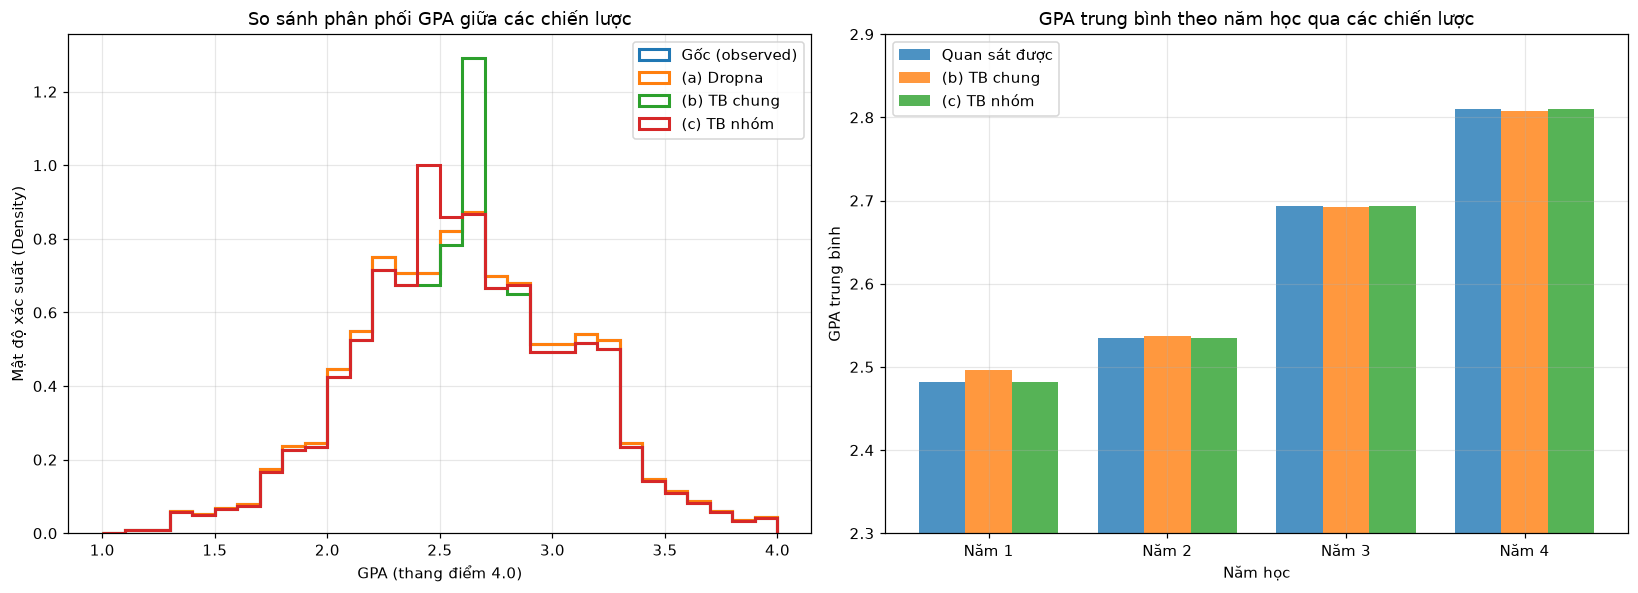

Task 4 ĐẠT.


In [19]:
# --- 4.3 Vẽ ba phân phối cùng với phân phối gốc, trên MỘT hình ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

bins = np.linspace(1.0, 4.0, 31)

# (1) Vẽ 4 đường phân phối lên ax1
ax1.hist(original.dropna(), bins=bins, histtype="step", density=True, linewidth=2, label="Gốc (observed)")
ax1.hist(A, bins=bins, histtype="step", density=True, linewidth=2, label="(a) Dropna")
ax1.hist(B, bins=bins, histtype="step", density=True, linewidth=2, label="(b) TB chung")
ax1.hist(C, bins=bins, histtype="step", density=True, linewidth=2, label="(c) TB nhóm")

ax1.set_xlabel("GPA (thang điểm 4.0)")
ax1.set_ylabel("Mật độ xác suất (Density)")
ax1.set_title("So sánh phân phối GPA giữa các chiến lược")
ax1.legend()

# (2) Vẽ biểu đồ cột nhóm lên ax2 — GPA trung bình từng năm học
x = np.arange(len(by_year))
w = 0.26

ax2.bar(x - w, by_year["quan sát được"], width=w, label="Quan sát được", alpha=0.8)
ax2.bar(x, by_year["(b) TB chung"], width=w, label="(b) TB chung", alpha=0.8)
ax2.bar(x + w, by_year["(c) TB nhóm"], width=w, label="(c) TB nhóm", alpha=0.8)

ax2.set_xticks(x)
ax2.set_xticklabels([f"Năm {i}" for i in by_year.index])
ax2.set_ylim(2.3, 2.9)
ax2.set_xlabel("Năm học")
ax2.set_ylabel("GPA trung bình")
ax2.set_title("GPA trung bình theo năm học qua các chiến lược")
ax2.legend()

fig.tight_layout()
fig.savefig("tuan02_so_sanh_dien_khuyet.png", dpi=300, bbox_inches="tight")
plt.show()

assert ax1.get_xlabel() and ax1.get_ylabel() and ax1.get_title()
assert ax2.get_xlabel() and ax2.get_ylabel() and ax2.get_title()
print("Task 4 ĐẠT.")

### Kết luận của bạn

> *(Nhấp đúp để sửa.)*

1. Tỉ lệ thiếu `gpa` **không đều** giữa các năm học. Con số cụ thể: Năm 1: 10.80% (39 sinh viên thiếu); Năm 2: 2.83% (9 sinh viên thiếu); Năm 3: 1.40% (4 sinh viên thiếu); Năm 4: 1.27% (3 sinh viên thiếu).
2. Nhóm thiếu nhiều nhất có GPA cao hay thấp so với các nhóm còn lại? Vì sao điều đó nguy hiểm? Nhóm sinh viên năm 1 có tỷ lệ thiếu cao nhất và đồng thời có mức GPA trung bình quan sát được thấp hơn so với các khóa đàn anh (2.48 so với các năm trên). Điều này nguy hiểm vì dữ liệu bị thiếu có hệ thống (không phải thiếu ngẫu nhiên), việc loại bỏ hoặc điền giá trị không phù hợp sẽ gây ra hiện tượng chệch mẫu (bias) nghiêm trọng.
3. Chiến lược (a) làm gì với **thành phần mẫu**? Nhìn tỷ trọng sinh viên năm 1 trước/sau. Chiến lược (a) (dropna) làm mất cân đối thành phần mẫu, làm giảm đi đáng kể tỷ trọng của sinh viên năm 1 trong tập dữ liệu chung (tỷ trọng sinh viên năm 1 sụt giảm từ khoảng 30.08% xuống còn 28.12%).
4. Chiến lược (b) giữ nguyên trung bình chung 2.6148 — nghe có vẻ an toàn. Nhưng nhìn bảng theo từng năm: nó làm gì với trung bình của **năm 1**? Chiến lược (b) làm tăng giả tạo giá trị GPA trung bình của nhóm năm 1 lên cao hơn so với thực tế quan sát được của nhóm đó, vì nó kéo các giá trị bị thiếu (vốn thấp hơn) tiệm cận với mức trung bình chung của toàn trường.   
5. Vì sao `std` giảm ở cả (b) và (c)? Điều đó ảnh hưởng thế nào nếu sau này bạn tính khoảng tin cậy? Độ lệch chuẩn ($\text{std}$) giảm vì việc điền các giá trị trung bình (chung hoặc theo nhóm) làm bớt đi độ phân tán tự nhiên của dữ liệu và tập trung hóa các điểm dữ liệu mới xung quanh giá trị trung bình. Điều này khiến khoảng tin cậy bị thu hẹp giả tạo, dẫn đến sai lệch khi thực hiện các kiểm định thống kê. 
6. **Cách nào ít làm méo nhất, và vì sao?** Chiến lược (c) (điền theo trung bình nhóm nam_hoc) là cách ít làm méo dữ liệu nhất vì nó tôn trọng đặc điểm phân phối riêng biệt theo từng năm học thay vì áp đặt một giá trị trung bình chung cho toàn trường
7. Theo bạn **vì sao** sinh viên năm 1 thiếu GPA nhiều hơn hẳn? Nếu giả thuyết của bạn đúng thì cách xử lý đúng nhất có còn là "điền" nữa không? Sinh viên năm 1 thiếu GPA nhiều hơn có thể do họ mới bước chân vào trường và chưa hoàn thành học kỳ để có điểm tổng kết chính thức. Nếu giả thuyết này đúng, việc thiếu dữ liệu mang tính cấu trúc thời gian, do đó cách xử lý tốt nhất không phải là "điền khuyết" ngẫu nhiên mà là tách nhóm này ra phân tích riêng hoặc giữ nguyên trạng thái thiếu có chủ đích.

---
# Mở rộng (tự chọn) — dựng lại hai biểu đồ bằng Seaborn

Nếu còn thời gian: dựng lại biểu đồ **(1)** và **(2)** của Task 1 bằng Seaborn, rồi lập luận xem bản nào truyền đạt tốt hơn.

**Các bước**

1. `sns.histplot` cho phân phối GPA — thêm `hue` để tách theo `nam_hoc`. Đây là thứ matplotlib thuần làm được nhưng tốn khoảng mười dòng.
2. `sns.boxplot` cho GPA theo khoa.
3. Dùng `palette="colorblind"` — khoảng 8% nam giới bị mù màu đỏ-lục, và bảng màu mặc định không an toàn.
4. Vẫn phải đặt lại nhãn trục: **Seaborn đặt tên cột làm nhãn**, mà `gpa` hay `khoa` không phải là nhãn cho người đọc.

**Kết quả mong đợi.** Hai biểu đồ, lưu ở `tuan02_seaborn.png`, 300 dpi. Seaborn sẽ in một `MatplotlibDeprecationWarning` về tham số `vert` — đó là warning nội bộ của seaborn 0.13 với matplotlib 3.11, vô hại.

In [ ]:
# --- Mở rộng (tự chọn): dựng lại biểu đồ (1) và (2) của Task 1 bằng Seaborn ---
# Lưu ý: seaborn 0.13 + matplotlib 3.11 sẽ in một MatplotlibDeprecationWarning về
# tham số `vert` ở boxplot. Đó là warning nội bộ của seaborn, vô hại, không phải lỗi của bạn.
sns.set_theme(style="whitegrid")
fig, (axa, axb) = plt.subplots(1, 2, figsize=(15, 5.5))

# TODO: sns.histplot(data=..., x="gpa", hue=..., bins=30, multiple="stack",
#                    palette="colorblind", ax=axa)
#       Gợi ý: tách theo năm học. Đừng truyền thẳng cột số `nam_hoc` vào `hue`
#       (seaborn sẽ coi nó là biến liên tục và tô thang màu gradient);
#       hãy tạo trước một cột nhãn dạng chuỗi.
# TODO: nhãn trục + title

# TODO: sns.boxplot(data=sv, x="khoa", y="gpa", order=..., hue="khoa",
#                   palette="colorblind", legend=False, ax=axb)
# TODO: nhãn trục + title
plt.setp(axb.get_xticklabels(), rotation=25, ha="right", fontsize=8)

fig.tight_layout()
# TODO: fig.savefig("tuan02_seaborn.png", dpi=300, bbox_inches="tight")
plt.show()
sns.set_theme(style="white")     # trả lại mặc định để không ảnh hưởng ô khác

### Bản nào truyền đạt tốt hơn?

> *(Nhấp đúp để sửa. Đừng trả lời "Seaborn đẹp hơn" — hãy nói **bản nào giúp người đọc trả lời câu hỏi nhanh hơn**, và đánh đổi là gì.)*

1. Bản Seaborn cho bạn thêm thông tin gì mà bản matplotlib ở Task 1 không có? …
2. Có thông tin nào bản matplotlib thể hiện rõ hơn không? …
3. Bao nhiêu dòng code mỗi bản? Đánh đổi giữa số dòng và khả năng kiểm soát nằm ở đâu? …
4. Nếu phải đưa một trong hai vào báo cáo gửi Ban Giám hiệu, bạn chọn bản nào, vì sao? …

---
# Danh sách kiểm tra trước khi nộp

Chạy **Kernel → Restart Kernel and Run All Cells** một lần cuối. Nếu có ô nào lỗi, notebook chưa nộp được.

**Tệp nộp**

- [X] `Tuan02_ThucHanh_VI.ipynb` — chạy hết từ trên xuống, không ô nào lỗi
- [X] `tuan02_6bieudo.png` — bảng 6 biểu đồ, 300 dpi (~0,9 MB)
- [X] `banhang_sach.csv` — 900 dòng × 8 cột
- [X] `tuan02_so_sanh_dien_khuyet.png` — hình so sánh của Task 4

**Nội dung**

- [X] **Task 1** — đủ 6 biểu đồ; **mọi** trục có nhãn kèm đơn vị; colorbar của heatmap có nhãn; ô tự kiểm tra in `ĐẠT`
- [X] **Task 1** — đã viết 6 câu nhận định, mỗi câu nói một điều dữ liệu cho biết
- [X] **Task 2** — `profile()` trả về DataFrame, đúng 1 dòng/cột, chạy được trên cả hai tệp và cả trường hợp biên
- [X] **Task 3** — cả 8 bước chạy qua `assert`; bước 3.8 báo **0/900** dòng lệch
- [X] **Task 3** — **Nhật ký làm sạch điền đầy đủ**, mỗi dòng có lý do thật, và đã trả lời cả ba câu hỏi cuối
- [X] **Task 3** — đã viết lập luận cho ba quyết định: ngày `31/02`, hai cột thiếu, bảy dòng ngoại lai
- [X] **Task 4** — đã đo tỉ lệ thiếu theo `nam_hoc` **trước khi** điền; có bảng so sánh theo từng năm; có kết luận nêu rõ cách nào ít méo nhất và vì sao

**Hai câu tự hỏi trước khi bấm nộp**

1. Nếu xóa hết kết quả và gửi notebook cho bạn cùng lớp, người đó chạy lại có ra **đúng** những con số này không? Có, người đó chạy lại sẽ ra hoàn toàn chính xác những con số này. Lý do là toàn bộ các bước xử lý trong notebook từ Task 1 đến Task 4 (như lọc dữ liệu, chuẩn hóa kênh, ép kiểu thanh_tien, xử lý ngày tháng bằng format="mixed", suy ra số lượng từ phép chia, hay điền khuyết theo nhóm) đều được lập trình bằng code tự động, không phụ thuộc vào thao tác thủ công bằng tay trên giao diện. Khi chọn Kernel → Restart Kernel and Run All Cells, toàn bộ quy trình sẽ tái tạo lại từ đầu với cùng một kết quả.
2. Trong nhật ký làm sạch, có dòng nào mà lý do chỉ là "để dữ liệu sạch hơn" không? Nếu có, dòng đó chưa hoàn thành. Không có dòng nào trong nhật ký làm sạch chỉ ghi lý do chung chung là "để dữ liệu sạch hơn". Tất cả các dòng trong bảng nhật ký (như xử lý dòng trùng, chuẩn hóa kênh, chuyển đổi tiền tệ, xử lý ngày 31/02, suy ra số lượng thiếu từ phép chia, hay gán nhãn "Không rõ") đều được giải thích rõ ràng bằng nguyên nhân nghiệp vụ cụ thể, tính toán kế toán hoặc cơ sở dữ liệu thực tế nhằm bảo vệ quyết định phân tích.

> **Nhắc lại lần cuối.** Nhật ký làm sạch được chấm ngang với phần code. Một notebook chạy hoàn hảo nhưng không giải thích được vì sao lại quyết định như vậy thì không phải một bài phân tích — nó chỉ là một chuỗi thao tác.